# CovBat example: GM parcels **or** HCP1065 tract segments vs **age**

**Data source:** nothing is read from ``derivatives/covbat/``. Scatter uses harmonized ``node*`` vs pre-CovBat ``node*_unharm``; black lines use the corresponding GAM predictions from the same CSVs (``node*_pred`` and ``node*_unharm_pred``). Curves are the mean prediction at each distinct age, connected with straight segments (no spline / scipy smoothing).

Each ``REGIONS`` entry is routed automatically:

- **White matter (pyAFQ / HCP1065):** keys that name a tract **segment** — suffix ``_end1``, ``_core``, ``_end2``, ``_end-core`` (same as **core**), or ``_end-<LETTER>`` where ``<LETTER>`` matches that tract's ``end1`` / ``end2`` anatomical code in ``data/atlases/HCP1065/HCP1065_tract_metadata.csv`` (e.g. ``ILF_L_end-A`` → end1 because ILF_L has ``end1`` = A). Data: **GAM outputs** ``derivatives/gam/pyafq/HCP1065/{tract}/`` (``_unharm`` / ``_unharm_pred`` for pre-harmonization; harmonized ``node*`` / ``node*_pred`` for post).

- **Grey matter (MNI parcels):** any other key. The notebook tries each atlas in **`MNI_MICRO_ATLASES`** (order matters) and uses the first where ``{parcel}_{SCALAR}_stat-mean_gam.csv`` exists under ``derivatives/gam/mni_micro/{atlas}/{parcel}/``. Keys may be dseg ``label`` / ``index`` for that atlas, a literal folder name, or ``REGION_PARCEL_BY_KEY`` override.

**Scalar:** set **`SCALAR`** (CSV stem / node column prefix).

**Outputs:** ``derivatives/analysis/covbat_example/`` and ``covbat_example_{SCALAR}_covbat_cohorts_legend.png``.


In [1]:
import json
import os
from os.path import join as ospj

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Georgia"]

AXIS_LABEL_FONTSIZE = 40
TICK_LABEL_FONTSIZE = 36
TITLE_PHASE_FONTSIZE = 44
TITLE_REGION_FONTSIZE = 38
TITLE_N_FONTSIZE = 32
LEGEND_ONLY_FONTSIZE = 30
LEGEND_STANDALONE_FIGSIZE_INCHES = (4.8 / 6, 4.2 / 6)
LEGEND_STANDALONE_FONTSIZE = max(5, LEGEND_ONLY_FONTSIZE // 6)
LEGEND_MARKER_POINT_SCALE = 0.275  # cohort dots in standalone legend use 2× this

plt.rcParams["axes.labelsize"] = AXIS_LABEL_FONTSIZE
plt.rcParams["xtick.labelsize"] = TICK_LABEL_FONTSIZE
plt.rcParams["ytick.labelsize"] = TICK_LABEL_FONTSIZE
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE = "__PROJECT_ROOT__"

WM_ATLAS = "HCP1065"
TRACT_METADATA_CSV = ospj(BASE, "data/atlases/HCP1065/HCP1065_tract_metadata.csv")

# CovBat GM atlases to try in order when inferring a parcel for a ``REGIONS`` key.
MNI_MICRO_ATLASES: tuple[str, ...] = ("4S156", "Glasser")

SCALAR = "dti_md"

REGIONS = {
    "UF_L_end-core": "Left uncinate fasciculus (core)"
}

REGION_PARCEL_BY_KEY: dict = {}

PLOT_SEX_SPECIFIC_FIGURES = False

GROUP_NAME_MAPPING = {
    "hcpya": "HCP-YA",
    "hcpaging": "HCP-Aging",
    "hcp_aging": "HCP-Aging",
    "penn_controls": "Penn controls",
    "penncontrols": "Penn controls",
}

CONTROL_GROUP_ORDER = ["penn_controls", "hcpya", "hcpaging"]

GROUP_COLORS = {
    "penn_controls": "#0173B2",
    "hcpya": "#029E73",
    "hcpaging": "#DE8F05",
}

FIG_OUT_DIR = ospj(BASE, "derivatives/analysis/covbat_example")

SCALAR_COLORS_JSON = ospj(BASE, "data/metadata/scalar_labels_to_colors.json")
SCALAR_HUMAN_JSON = ospj(BASE, "data/metadata/scalar_labels_to_human.json")

REGION_NAME_MAPPING = {
    "LH_Hippocampus": "Left Hippocampus",
    "RH_Hippocampus": "Right Hippocampus",
}

SCATTER_S = 140
SCATTER_ALPHA = 0.45

MODEL_FIT_LINEWIDTH = 3.6
MODEL_FIT_COLOR = "#000000"

# Standalone legend proxies: same marker / line weights for CovBat cohort legend and normative GAM legend.
_LEGEND_MS_2D_BASE = float(np.sqrt(SCATTER_S) / 2.4)
LEGEND_PROXY_MARKERSIZE = _LEGEND_MS_2D_BASE * LEGEND_MARKER_POINT_SCALE * 2.0 * 1.22  # cohort + normative (slightly enlarged for standalone PNGs)
LEGEND_PROXY_LINEWIDTH_FIT = max(0.55, MODEL_FIT_LINEWIDTH / 6)

# Shared panel height (in): 1×2 CovBat uses full width; normative GAM uses half width, same height.
PANEL_FIGSIZE_HEIGHT_IN = 8.4
SIDE_BY_SIDE_FIGSIZE = (20.0, PANEL_FIGSIZE_HEIGHT_IN)
# Match ``tight_layout`` padding between pre/post and normative figures.
FIG_TIGHT_LAYOUT_RECT = (0.0, 0.0, 1.0, 0.97)


In [2]:
import re

_scalar_colors_map: dict | None = None
_scalar_human_map: dict | None = None

# (DataFrame, frozenset of parcel labels) keyed by parcel atlas name (e.g. "4S156", "Glasser")
_DSEG_CACHE: dict[str, tuple[pd.DataFrame, frozenset[str]]] = {}


def _scalar_label_maps() -> tuple[dict, dict]:
    global _scalar_colors_map, _scalar_human_map
    if _scalar_colors_map is None:
        with open(SCALAR_COLORS_JSON, encoding="utf-8") as f:
            _scalar_colors_map = json.load(f)
        with open(SCALAR_HUMAN_JSON, encoding="utf-8") as f:
            _scalar_human_map = json.load(f)
    return _scalar_colors_map, _scalar_human_map


def scalar_axis_label_text(scalar_key: str) -> str:
    _, human_map = _scalar_label_maps()
    raw = human_map.get(scalar_key, scalar_key.replace("_", " "))
    if raw.endswith(")") and " (" in raw:
        return raw.rsplit(" (", 1)[0].strip()
    return raw


def scalar_axis_label_color(scalar_key: str) -> str:
    colors, _ = _scalar_label_maps()
    return colors.get(scalar_key, "#000000")


def _default_atlas_dseg_path(atlas_name: str) -> str:
    if atlas_name == "4S156":
        return ospj(BASE, "data/atlases/4S/atlas-4S156Parcels_dseg.tsv")
    if atlas_name == "Glasser":
        return ospj(BASE, "data/atlases/Glasser/atlas-Glasser_dseg.tsv")
    raise ValueError(
        f"Unknown parcel atlas {atlas_name!r}: extend _default_atlas_dseg_path() or adjust MNI_MICRO_ATLASES."
    )


def load_atlas_dseg(atlas_name: str) -> pd.DataFrame:
    """Atlas parcel ``index`` ↔ ``label``; CovBat GM folder names match ``label``."""
    if atlas_name not in _DSEG_CACHE:
        path = _default_atlas_dseg_path(atlas_name)
        df = pd.read_csv(path, sep="\t")
        if "index" not in df.columns or "label" not in df.columns:
            raise ValueError(f"{path} must contain 'index' and 'label' columns")
        df = df.copy()
        idx = pd.to_numeric(df["index"], errors="coerce")
        if idx.isna().any():
            raise ValueError(f"Non-numeric 'index' values in {path}")
        df["index"] = idx.astype(int)
        df["label"] = df["label"].astype(str)
        _DSEG_CACHE[atlas_name] = (df, frozenset(df["label"]))
    return _DSEG_CACHE[atlas_name][0]


def _atlas_parcel_labels(atlas_name: str) -> frozenset[str]:
    load_atlas_dseg(atlas_name)
    return _DSEG_CACHE[atlas_name][1]


def parcel_label_from_atlas_index(idx: int, atlas_name: str) -> str:
    d = load_atlas_dseg(atlas_name)
    row = d.loc[d["index"] == int(idx)]
    if row.empty:
        raise KeyError(f"No dseg row with index=={idx!r} for atlas {atlas_name!r}")
    return str(row.iloc[0]["label"])


def parcel_folder_for_region_key(region_key: str | int, atlas_name: str) -> str:
    """CovBat parcel directory within ``atlas_name`` (dseg label, dseg index, or literal folder)."""
    if region_key in REGION_PARCEL_BY_KEY:
        return REGION_PARCEL_BY_KEY[region_key]
    if isinstance(region_key, int):
        return parcel_label_from_atlas_index(region_key, atlas_name)
    if isinstance(region_key, str) and region_key.isdigit():
        return parcel_label_from_atlas_index(int(region_key), atlas_name)
    rk = str(region_key)
    if rk in _atlas_parcel_labels(atlas_name):
        return rk
    return rk


def human_readable_region(region_key: str | int, parcel: str) -> str:
    if region_key in REGIONS:
        return REGIONS[region_key]
    if parcel in REGION_NAME_MAPPING:
        return REGION_NAME_MAPPING[parcel]
    return parcel.replace("_", " ").replace("-", " ")


# HCP1065 tract thirds (1-based node indices inclusive); structural_tractometry_context.md
END1_NODES = tuple(range(1, 35))
CORE_NODES = tuple(range(35, 67))
END2_NODES = tuple(range(67, 101))

AGEPLOT_OBS = "__ageplot_obs"
AGEPLOT_PRED = "__ageplot_pred"


_tract_meta_by_label: pd.DataFrame | None = None


def _load_tract_metadata() -> pd.DataFrame:
    """Cached HCP1065 tract metadata (``label``, ``end1``, ``end2``, …)."""
    global _tract_meta_by_label
    if _tract_meta_by_label is None:
        _tract_meta_by_label = pd.read_csv(TRACT_METADATA_CSV)
    return _tract_meta_by_label


def parse_pyafq_wm_region_key(region_key: str) -> tuple[str, str]:
    """Parse ``{tract}_{segment}`` (e.g. ``UF_L_end-core``) → (tract ``label``, segment token)."""
    s = str(region_key)
    meta = _load_tract_metadata()
    valid = set(meta["label"].astype(str))
    for suf, seg in (
        ("_end-core", "end-core"),
        ("_end1", "end1"),
        ("_end2", "end2"),
        ("_core", "core"),
    ):
        if s.endswith(suf):
            tract = s[: -len(suf)]
            if tract in valid:
                return tract, seg
    m = re.match(r"^(.+)_end-(.+)$", s)
    if m:
        tract, code = m.group(1), m.group(2)
        if tract in valid:
            return tract, f"end-{code}"
    raise ValueError(f"Not a WM region key or unknown tract: {region_key!r}")


def is_wm_region_key(region_key: str | int) -> bool:
    if not isinstance(region_key, str):
        return False
    try:
        parse_pyafq_wm_region_key(region_key)
        return True
    except ValueError:
        return False


def wm_segment_node_indices(tract: str, segment: str) -> list[int]:
    """1-based along-tract node indices for an HCP1065 segment name."""
    if segment in ("core", "end-core"):
        return list(CORE_NODES)
    if segment == "end1":
        return list(END1_NODES)
    if segment == "end2":
        return list(END2_NODES)
    if segment.startswith("end-") and segment != "end-core":
        code = segment[len("end-") :]
        meta = _load_tract_metadata()
        row = meta.loc[meta["label"].astype(str) == tract]
        if row.empty:
            raise ValueError(f"No metadata row for tract {tract!r}")
        r0 = row.iloc[0]
        e1, e2 = str(r0["end1"]), str(r0["end2"])
        if e1 == code:
            return list(END1_NODES)
        if e2 == code:
            return list(END2_NODES)
        raise ValueError(
            f"End code {code!r} does not match end1={e1!r} or end2={e2!r} for tract {tract!r}"
        )
    raise ValueError(f"Unknown segment {segment!r} for tract {tract!r}")


def filter_sex(df: pd.DataFrame, sex_subset: str) -> pd.DataFrame:
    """Restrict rows by ``sex``; ``sex_subset`` is ``both`` | ``females`` | ``males``."""
    if sex_subset == "both":
        return df
    if sex_subset == "females":
        return df.loc[df["sex"] == "F"].copy()
    if sex_subset == "males":
        return df.loc[df["sex"] == "M"].copy()
    raise ValueError(f"Unknown sex_subset: {sex_subset!r}")

def _gam_wm_csv_path(tract: str) -> str:
    return ospj(
        BASE,
        "derivatives/gam/pyafq",
        WM_ATLAS,
        tract,
        f"{tract}_{SCALAR}_stat-mean_gam.csv",
    )


def _gam_gm_csv_path(parcel: str, mni_atlas: str) -> str:
    return ospj(
        BASE,
        "derivatives/gam/mni_micro",
        mni_atlas,
        parcel,
        f"{parcel}_{SCALAR}_stat-mean_gam.csv",
    )


def _wm_gam_segment_column_sets(tract: str, segment: str) -> tuple[list[str], list[str], list[str], list[str]]:
    """Harmonized (node, node_pred) and unharmonized (node_unharm, node_unharm_pred) column lists."""
    nodes = wm_segment_node_indices(tract, segment)
    harm = [f"node{n}" for n in nodes]
    harm_p = [f"node{n}_pred" for n in nodes]
    unh = [f"node{n}_unharm" for n in nodes]
    unh_p = [f"node{n}_unharm_pred" for n in nodes]
    return harm, harm_p, unh, unh_p


def gam_tract_csv_ready(tract: str) -> bool:
    p = _gam_wm_csv_path(tract)
    if not os.path.isfile(p):
        return False
    try:
        hdr = pd.read_csv(p, nrows=0)
    except Exception:
        return False
    need = ("node1", "node1_pred", "node1_unharm", "node1_unharm_pred")
    return all(c in hdr.columns for c in need)


def gam_parcel_csv_ready(parcel: str, mni_atlas: str) -> bool:
    p = _gam_gm_csv_path(parcel, mni_atlas)
    if not os.path.isfile(p):
        return False
    try:
        hdr = pd.read_csv(p, nrows=0)
    except Exception:
        return False
    u, up = f"{SCALAR}_unharm", f"{SCALAR}_unharm_pred"
    v, vp = SCALAR, f"{SCALAR}_pred"
    return all(c in hdr.columns for c in (u, up, v, vp))


def gam_region_ready(region_key: str | int) -> bool:
    if is_wm_region_key(region_key):
        try:
            tract, _ = parse_pyafq_wm_region_key(region_key)
        except (ValueError, KeyError):
            return False
        return gam_tract_csv_ready(tract)
    return resolve_gm_parcel_atlas(region_key) is not None


def resolve_gm_parcel_atlas(region_key: str | int) -> tuple[str, str] | None:
    """Return ``(parcel_folder, mni_atlas)`` for the first atlas with a GAM stat-mean CSV."""
    if region_key in REGION_PARCEL_BY_KEY:
        p = REGION_PARCEL_BY_KEY[region_key]
        for atlas_name in MNI_MICRO_ATLASES:
            if gam_parcel_csv_ready(p, atlas_name):
                return (p, atlas_name)
        return None
    for atlas_name in MNI_MICRO_ATLASES:
        p = parcel_folder_for_region_key(region_key, atlas_name)
        if gam_parcel_csv_ready(p, atlas_name):
            return (p, atlas_name)
    s = str(region_key)
    for atlas_name in MNI_MICRO_ATLASES:
        if gam_parcel_csv_ready(s, atlas_name):
            return (s, atlas_name)
    return None


def load_before_after_harmonization_from_gam(
    region_key: str | int,
) -> tuple[pd.DataFrame, pd.DataFrame, str, str]:
    """Pre- and post-harmonization control rows from GAM outputs (same fits as normative GAM panel).

    Each returned frame includes ``AGEPLOT_OBS`` (scatter) and ``AGEPLOT_PRED`` (GAM prediction line).
    """
    if is_wm_region_key(region_key):
        tract, seg = parse_pyafq_wm_region_key(region_key)
        csv_path = _gam_wm_csv_path(tract)
        if not os.path.isfile(csv_path):
            raise FileNotFoundError(csv_path)
        df0 = pd.read_csv(csv_path)
        h, hp, u, up = _wm_gam_segment_column_sets(tract, seg)
        miss = [c for c in h + hp + u + up if c not in df0.columns]
        if miss:
            raise KeyError(
                f"GAM CSV missing columns (re-run GAM script with unharm outputs?): "
                f"{miss[:10]!r} … ({csv_path})"
            )
        base = df0.copy()
        base = base[base["group"] != "penn_epilepsy"].copy()
        pre = base.copy()
        pre[AGEPLOT_OBS] = pre[u].mean(axis=1, skipna=True)
        pre[AGEPLOT_PRED] = pre[up].mean(axis=1, skipna=True)
        post = base.copy()
        post[AGEPLOT_OBS] = post[h].mean(axis=1, skipna=True)
        post[AGEPLOT_PRED] = post[hp].mean(axis=1, skipna=True)
        stem_base = str(region_key).replace("/", "-")
        return pre, post, tract, stem_base

    gm = resolve_gm_parcel_atlas(region_key)
    if gm is None:
        raise ValueError(f"No GAM CSV for {region_key!r} under derivatives/gam/mni_micro")
    parcel, mni_atlas = gm
    csv_path = _gam_gm_csv_path(parcel, mni_atlas)
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(csv_path)
    df0 = pd.read_csv(csv_path)
    uc, upc = f"{SCALAR}_unharm", f"{SCALAR}_unharm_pred"
    vc, vpc = SCALAR, f"{SCALAR}_pred"
    miss = [c for c in (uc, upc, vc, vpc) if c not in df0.columns]
    if miss:
        raise KeyError(f"GAM CSV missing {miss!r} in {csv_path}")
    base = df0.copy()
    base = base[base["group"] != "penn_epilepsy"].copy()
    pre = base.copy()
    pre[AGEPLOT_OBS] = pre[uc].astype(float)
    pre[AGEPLOT_PRED] = pre[upc].astype(float)
    post = base.copy()
    post[AGEPLOT_OBS] = post[vc].astype(float)
    post[AGEPLOT_PRED] = post[vpc].astype(float)
    return pre, post, parcel, parcel


def _mean_gam_pred_by_unique_age(
    sub: pd.DataFrame,
    pred_col: str,
) -> tuple[np.ndarray, np.ndarray] | None:
    """For each distinct age, mean of ``pred_col`` (GAM CSV predictions only); ages sorted.

    Matplotlib draws straight segments between ages — no scipy smoothing."""
    if sub.empty or pred_col not in sub.columns or "age" not in sub.columns:
        return None
    m = sub[["age", pred_col]].notna().all(axis=1)
    if not m.any():
        return None
    xy = (
        sub.loc[m, ["age", pred_col]]
        .groupby("age", as_index=False)[pred_col]
        .mean()
        .sort_values("age", kind="mergesort")
    )
    xs = xy["age"].to_numpy(dtype=float)
    ys = xy[pred_col].to_numpy(dtype=float)
    if xs.size < 2 or not np.all(np.isfinite(xs)) or not np.all(np.isfinite(ys)):
        return None
    return xs, ys



def ylim_from_pair(
    df_before: pd.DataFrame,
    df_after: pd.DataFrame,
    col_before: str,
    col_after: str,
    margin_frac: float = 0.04,
) -> tuple[float, float]:
    blocks: list[np.ndarray] = []
    for df, col in ((df_before, col_before), (df_after, col_after)):
        if df is None or df.empty or col not in df.columns:
            continue
        v = df[col].to_numpy(dtype=float)
        v = v[np.isfinite(v)]
        if v.size:
            blocks.append(v)
    if not blocks:
        return (0.0, 1.0)
    v = np.concatenate(blocks)
    lo, hi = float(np.min(v)), float(np.max(v))
    span = hi - lo
    if span <= 0:
        pad = max(abs(hi), 1e-9) * margin_frac
        return (lo - pad, hi + pad)
    pad = span * margin_frac
    return (lo - pad, hi + pad)


def _set_covbat_ageplot_title(
    ax: plt.Axes,
    *,
    before: bool,
    region_display: str,
    n_subj: int,
    sex_label: str,
    show_subject_count: bool = True,
) -> None:
    _ = before
    ax.set_title("")
    ax.text(
        0.5,
        1.045,
        region_display,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=TITLE_REGION_FONTSIZE,
        fontweight="normal",
    )
    if show_subject_count:
        ax.text(
            0.5,
            1.008,
            f"n = {n_subj} {sex_label}",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=TITLE_N_FONTSIZE,
            fontweight="normal",
        )


def _cohort_legend_proxy_handles(
    df: pd.DataFrame,
    *,
    marker_scale: float = 1.0,
) -> tuple[list, list]:
    """Marker proxies; ``marker_scale`` enlarges dots for the standalone PNG."""
    from matplotlib.lines import Line2D

    handles: list = []
    labels: list = []
    _ref = LEGEND_MARKER_POINT_SCALE * 2.0
    ms = float(LEGEND_PROXY_MARKERSIZE) * (float(marker_scale) / _ref)
    for g in CONTROL_GROUP_ORDER:
        sub = df[df["group"] == g]
        if sub.empty:
            continue
        color = GROUP_COLORS.get(g, "#666666")
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="o",
                markersize=ms,
                markerfacecolor=color,
                markeredgecolor="none",
            )
        )
        labels.append(GROUP_NAME_MAPPING.get(g, g))
    return handles, labels


def standalone_legend_proxy_handles(
    df: pd.DataFrame,
) -> tuple[tuple[list, list], tuple[list, list]]:
    """(cohort handles, cohort labels), (fit handles, fit labels) for ``save_cohort_legend_figure`` (single combined PNG)."""
    from matplotlib.lines import Line2D

    h, lab = _cohort_legend_proxy_handles(df, marker_scale=LEGEND_MARKER_POINT_SCALE * 2.0)
    line_f = Line2D(
        [0],
        [0],
        color=MODEL_FIT_COLOR,
        linestyle=":",
        linewidth=LEGEND_PROXY_LINEWIDTH_FIT,
    )
    line_m = Line2D(
        [0],
        [0],
        color=MODEL_FIT_COLOR,
        linestyle="--",
        linewidth=LEGEND_PROXY_LINEWIDTH_FIT,
    )
    return (h, lab), ([line_f, line_m], ["Female mean", "Male mean"])


def plot_roi_before_after_side_by_side(
    df_pre: pd.DataFrame,
    df_post: pd.DataFrame,
    *,
    region_key: str | int,
    parcel: str,
    sex_subset: str,
    ylim: tuple[float, float] | None = None,
) -> tuple[plt.Figure, list, list]:
    """Single row Before | After; no legend on the figure panels.

    Points: ``AGEPLOT_OBS`` (``node*_unharm`` vs ``node*`` segment means). Lines: ``AGEPLOT_PRED`` from the
    same GAM CSVs (``node*_unharm_pred`` vs ``node*_pred``), aggregated like the scatter. ``both`` sexes:
    female (dotted) and male (dashed) curves; each is mean GAM prediction at each age, straight segments only.
    """
    region_display = human_readable_region(region_key, parcel)
    if sex_subset == "both":
        sex_label = "Both sexes"
    else:
        sex_label = "Females" if sex_subset == "females" else "Males"
    pooled_both_sexes = sex_subset == "both"

    _ylabel = scalar_axis_label_text(SCALAR)
    _ylabel_color = scalar_axis_label_color(SCALAR)

    fig, axes = plt.subplots(1, 2, figsize=SIDE_BY_SIDE_FIGSIZE, sharey=True)
    ax_pre, ax_post = axes[0], axes[1]

    for ax, df, before in (
        (ax_pre, df_pre, True),
        (ax_post, df_post, False),
    ):
        if (
            df.empty
            or AGEPLOT_OBS not in df.columns
            or AGEPLOT_PRED not in df.columns
        ):
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=AXIS_LABEL_FONTSIZE,
            )
            _set_covbat_ageplot_title(
                ax,
                before=before,
                region_display=region_display,
                n_subj=0,
                sex_label=sex_label,
                show_subject_count=not pooled_both_sexes,
            )
            continue

        for g in CONTROL_GROUP_ORDER:
            sub = df[df["group"] == g]
            if sub.empty:
                continue
            color = GROUP_COLORS.get(g, "#666666")
            ax.scatter(
                sub["age"],
                sub[AGEPLOT_OBS],
                alpha=SCATTER_ALPHA,
                s=SCATTER_S,
                color=color,
                edgecolors="none",
                zorder=3,
            )

        if pooled_both_sexes:
            c_f = _mean_gam_pred_by_unique_age(filter_sex(df, "females"), AGEPLOT_PRED)
            c_m = _mean_gam_pred_by_unique_age(filter_sex(df, "males"), AGEPLOT_PRED)
            if c_f is not None:
                xs, ys = c_f
                ax.plot(
                    xs,
                    ys,
                    color=MODEL_FIT_COLOR,
                    linestyle=":",
                    linewidth=MODEL_FIT_LINEWIDTH,
                    zorder=2,
                    solid_capstyle="round",
                )
            if c_m is not None:
                xs, ys = c_m
                ax.plot(
                    xs,
                    ys,
                    color=MODEL_FIT_COLOR,
                    linestyle="--",
                    linewidth=MODEL_FIT_LINEWIDTH,
                    zorder=2,
                    solid_capstyle="round",
                )
        else:
            curve = _mean_gam_pred_by_unique_age(df, AGEPLOT_PRED)
            if curve is not None:
                xs, ys = curve
                ax.plot(
                    xs,
                    ys,
                    color=MODEL_FIT_COLOR,
                    linewidth=MODEL_FIT_LINEWIDTH,
                    zorder=2,
                    solid_capstyle="round",
                )

        ax.set_xlabel("Age (years)", fontsize=AXIS_LABEL_FONTSIZE)
        ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_FONTSIZE, colors="black")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.grid(True, alpha=0.3)
        _set_covbat_ageplot_title(
            ax,
            before=before,
            region_display=region_display,
            n_subj=len(df),
            sex_label=sex_label,
            show_subject_count=not pooled_both_sexes,
        )

    ax_pre.set_ylabel(_ylabel, fontsize=AXIS_LABEL_FONTSIZE, color=_ylabel_color)
    ax_pre.yaxis.label.set_color(_ylabel_color)

    if ylim is not None:
        ax_pre.set_ylim(ylim)
        ax_post.set_ylim(ylim)

    fig.tight_layout(rect=FIG_TIGHT_LAYOUT_RECT)
    return fig, [], []



def save_fig_png(fig: plt.Figure, stem: str) -> str:
    os.makedirs(FIG_OUT_DIR, exist_ok=True)
    path = ospj(FIG_OUT_DIR, f"{stem}.png")
    fig.savefig(path, bbox_inches="tight", dpi=300)
    return path


def save_cohort_legend_figure(
    cohort_handles: list,
    cohort_labels: list,
    fit_handles: list,
    fit_labels: list,
    stem: str,
    *,
    figsize: tuple[float, float] | None = None,
) -> str:
    """One standalone legend PNG: cohort entries then fit entries in a single one-column box."""
    os.makedirs(FIG_OUT_DIR, exist_ok=True)
    path = ospj(FIG_OUT_DIR, f"{stem}_legend.png")
    _handles = list(cohort_handles) + list(fit_handles)
    _labels = list(cohort_labels) + list(fit_labels)
    n = len(_handles)
    if figsize is None:
        w0, h0 = LEGEND_STANDALONE_FIGSIZE_INCHES
        _fs = (w0 * 1.2, h0 * max(1.6, 0.45 + 0.4 * n))
    else:
        _fs = figsize
    fig = plt.figure(figsize=_fs)
    fig.legend(
        _handles,
        _labels,
        loc="center",
        ncol=1,
        frameon=True,
        fontsize=LEGEND_STANDALONE_FONTSIZE,
        handlelength=2.2,
    )
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=300)
    plt.close(fig)
    return path


def assert_scalar_metadata_key() -> None:
    """Warn if ``SCALAR`` is missing from ``scalar_labels_to_human.json`` (axis label still falls back)."""
    _, human = _scalar_label_maps()
    if SCALAR not in human:
        import warnings

        sample = ", ".join(sorted(human)[:8])
        warnings.warn(
            f"SCALAR={SCALAR!r} not in scalar_labels_to_human.json — check spelling / regenerate CSVs. "
            f"Example keys: {sample}, ...",
            stacklevel=2,
        )


assert_scalar_metadata_key()



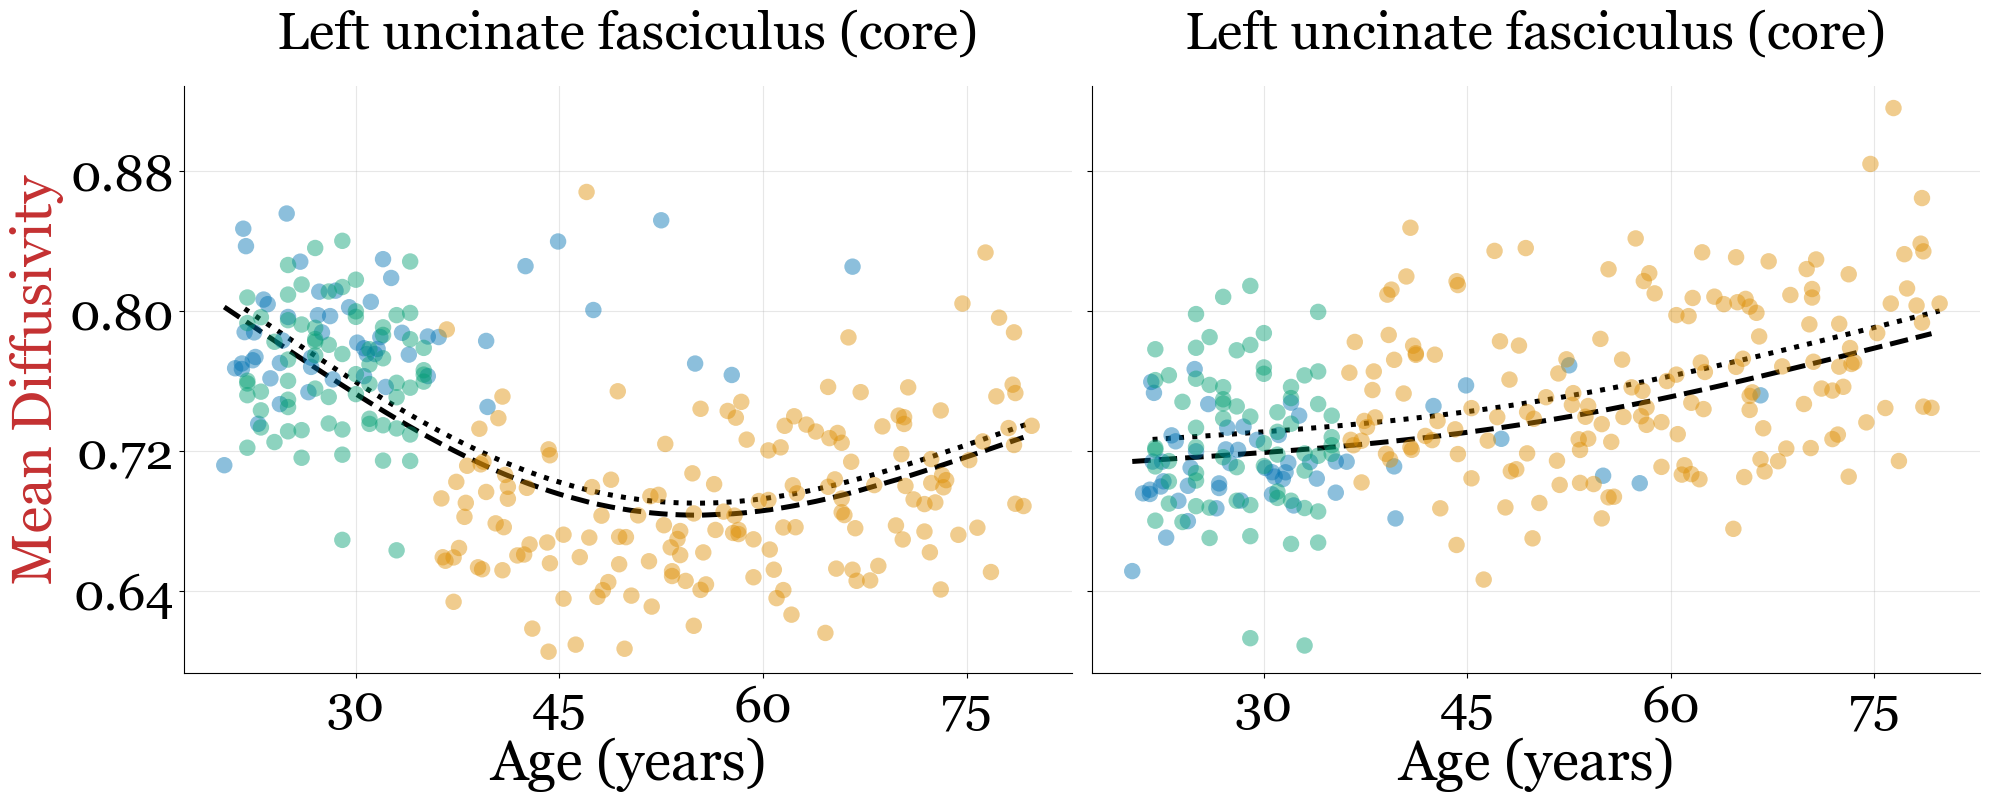

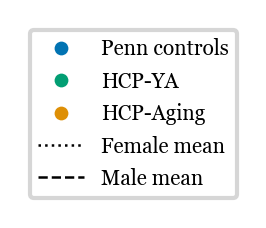

In [3]:
from IPython.display import Image, display

legend_png = None
cohort_legend_df = None

for region_key in REGIONS:
    if is_wm_region_key(region_key):
        if not gam_region_ready(region_key):
            print(
                f"Skipping {region_key!r}: missing pyAFQ GAM CSV under "
                f"derivatives/gam/pyafq/{WM_ATLAS}/{{tract}}/"
            )
            continue
        df_pre_all, df_post_all, parcel, stem_base = load_before_after_harmonization_from_gam(
            region_key
        )
    else:
        if resolve_gm_parcel_atlas(region_key) is None:
            print(
                f"Skipping {region_key!r}: no GAM stat-mean CSV under mni_micro for "
                f"any of {MNI_MICRO_ATLASES}"
            )
            continue
        df_pre_all, df_post_all, parcel, stem_base = load_before_after_harmonization_from_gam(
            region_key
        )

    if cohort_legend_df is None:
        cohort_legend_df = df_pre_all

    _sex_loop: list[str] = []
    if PLOT_SEX_SPECIFIC_FIGURES:
        _sex_loop.extend(["females", "males"])
    _sex_loop.append("both")

    for sex_subset in _sex_loop:
        df_pre = filter_sex(df_pre_all, sex_subset)
        df_post = filter_sex(df_post_all, sex_subset)
        _lo_o, _hi_o = ylim_from_pair(df_pre, df_post, AGEPLOT_OBS, AGEPLOT_OBS)
        _lo_p, _hi_p = ylim_from_pair(df_pre, df_post, AGEPLOT_PRED, AGEPLOT_PRED)
        _shared_ylim = (min(_lo_o, _lo_p), max(_hi_o, _hi_p))
        if sex_subset == "both":
            _stem = f"{stem_base}_{SCALAR}_covbat_both_sexes"
        else:
            _stem = f"{stem_base}_{SCALAR}_covbat_{sex_subset}"

        fig, _, _ = plot_roi_before_after_side_by_side(
            df_pre,
            df_post,
            region_key=region_key,
            parcel=parcel,
            sex_subset=sex_subset,
            ylim=_shared_ylim,
        )
        save_fig_png(fig, _stem)
        plt.show()
        plt.close(fig)

if cohort_legend_df is not None:
    (_ch, _cl), (_fh, _fl) = standalone_legend_proxy_handles(cohort_legend_df)
    legend_png = save_cohort_legend_figure(_ch, _cl, _fh, _fl, f"covbat_example_{SCALAR}_covbat_cohorts")

if legend_png:
    display(Image(filename=legend_png))


## Normative GAM illustration (single panel)

One **normative GAM** figure (plus **one** combined standalone legend PNG) is written for **each key** in **`REGIONS`**, using the same scalar / WM vs GM routing as the side-by-side plots above.

**Configure** optional red marker: **`GAM_EXAMPLE_MARKER`** (`None` = use **`GAM_EXAMPLE_FEMALE_AGE`** / **`GAM_EXAMPLE_FEMALE_Y`** with sex **F** on every ROI; `{}` = no marker; or a per-key dict mapping to ``(age, y)`` or ``(age, y, sex)`` with ``sex`` ``"F"`` / ``"M"``). When a marker is drawn, the cell **prints** age, sex, and the **z-score** vs the sex-matched normative GAM (male uses the male control fit when available; otherwise a warning and the female fit). If a CSV row matches the marker (age / ``__y_obs`` within small tolerances), it also prints that subject’s ``sub`` and mean-segment ``__y_z`` from the file.

WM: ``derivatives/gam/pyafq/HCP1065/{tract}/{tract}_{scalar}_stat-mean_gam.csv``. GM: ``derivatives/gam/mni_micro/{atlas}/{parcel}/``.

**Outputs:** ``normative_gam_{stem}_{scalar}.png`` and ``normative_gam_{stem}_{scalar}_legend.png`` (cohort markers + female-fit / residual band proxies) under ``derivatives/analysis/covbat_example/``. After the loop, the notebook displays the **last** ROI’s legend PNG in the cell output.


  Example patient marker ('UF_L_end-core'): age=NA sex=NA (harmonized); z_vs_female_normative_GAM=3.34787 (pred@age=0.754919, residual_sd=0.0403482)


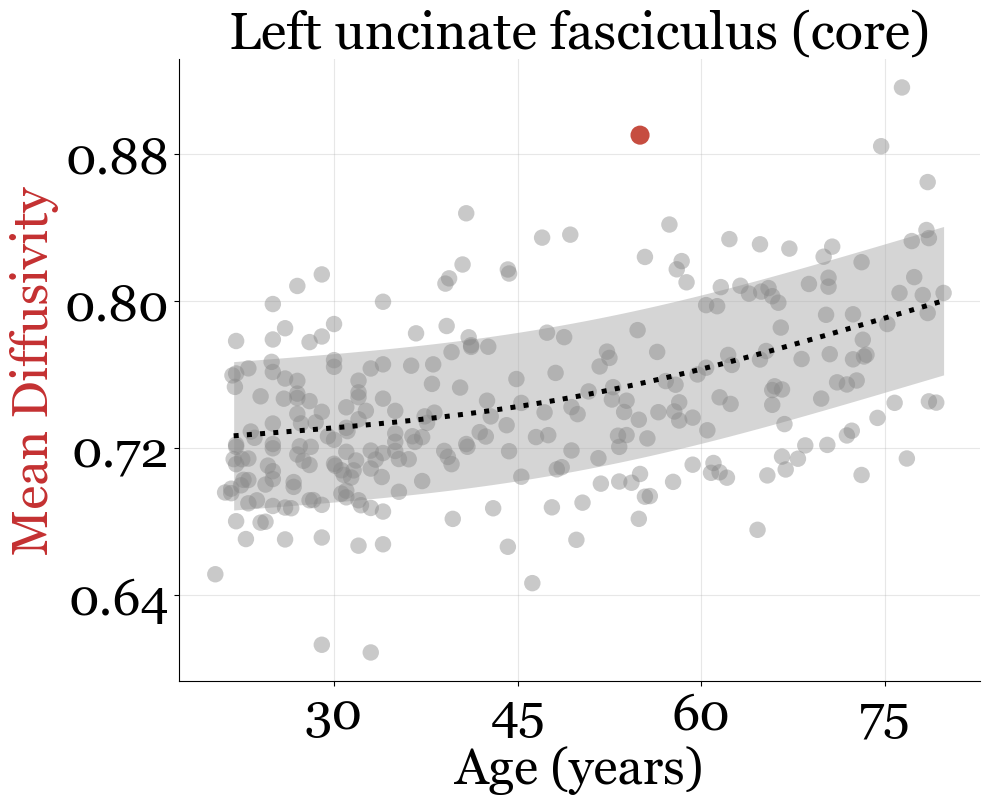

Wrote '__PROJECT_ROOT__/derivatives/analysis/covbat_example/normative_gam_UF_L_end-core_dti_md.png'
Wrote '__PROJECT_ROOT__/derivatives/analysis/covbat_example/normative_gam_UF_L_end-core_dti_md_legend.png'


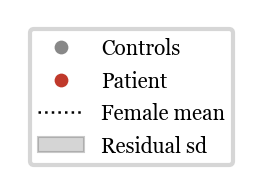

In [4]:
# --- Normative GAM single-panel figures (one file set per key in ``REGIONS``) ---
# Red example marker: set ``GAM_EXAMPLE_MARKER`` to ``None`` to use the same ``(age, y)`` for every ROI
# (only meaningful when y is comparable across ROIs). Use ``{}`` to omit the marker everywhere, or a
# dict ``{region_key: (age, y)}`` or ``(age, y, sex)`` with sex ``F``/``M`` (default ``F``) for z-score context.
GAM_EXAMPLE_MARKER: dict[str, tuple[float, float]] | None = None
GAM_EXAMPLE_FEMALE_AGE = 55.0
GAM_EXAMPLE_FEMALE_Y = 0.89

from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

_pan_w, _pan_h = SIDE_BY_SIDE_FIGSIZE
NORMATIVE_GAM_FIGSIZE = (_pan_w / 2.0, _pan_h)
NORMATIVE_AXIS_LABEL_FONTSIZE = AXIS_LABEL_FONTSIZE * 0.9


def load_gam_stat_mean_df(region_key: str) -> tuple[pd.DataFrame, str, str]:
    """Return (gam_df, stem_for_filename, domain 'wm'|'gm')."""
    if is_wm_region_key(region_key):
        tract, seg = parse_pyafq_wm_region_key(region_key)
        csv_path = ospj(
            BASE,
            "derivatives/gam/pyafq",
            WM_ATLAS,
            tract,
            f"{tract}_{SCALAR}_stat-mean_gam.csv",
        )
        if not os.path.isfile(csv_path):
            raise FileNotFoundError(csv_path)
        df = pd.read_csv(csv_path)
        nodes = wm_segment_node_indices(tract, seg)
        obs_cols = [f"node{n}" for n in nodes]
        pred_cols = [f"node{n}_pred" for n in nodes]
        miss = [c for c in obs_cols + pred_cols if c not in df.columns]
        if miss:
            raise KeyError(f"GAM CSV missing columns {miss[:8]}… for {region_key!r}")
        z_cols = [f"node{n}_z" for n in nodes]
        miss_z = [c for c in z_cols if c not in df.columns]
        out = df.copy()
        out["__y_obs"] = out[obs_cols].mean(axis=1, skipna=True)
        out["__y_pred"] = out[pred_cols].mean(axis=1, skipna=True)
        if miss_z:
            out["__y_z"] = np.nan
        else:
            out["__y_z"] = out[z_cols].mean(axis=1, skipna=True)
        stem = str(region_key).replace("/", "-")
        return out, stem, "wm"
    gm = resolve_gm_parcel_atlas(region_key)
    if gm is None:
        raise ValueError(
            f"No CovBat/GAM parcel resolved for {region_key!r} (check MNI_MICRO_ATLASES / data)"
        )
    parcel, mni_atlas = gm
    csv_path = ospj(
        BASE,
        "derivatives/gam/mni_micro",
        mni_atlas,
        parcel,
        f"{parcel}_{SCALAR}_stat-mean_gam.csv",
    )
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(csv_path)
    df = pd.read_csv(csv_path)
    v, vp = SCALAR, f"{SCALAR}_pred"
    if v not in df.columns or vp not in df.columns:
        raise KeyError(f"Expected {v!r} and {vp!r} in {csv_path}")
    out = df.copy()
    out["__y_obs"] = out[v]
    out["__y_pred"] = out[vp]
    zc = f"{SCALAR}_z"
    out["__y_z"] = out[zc] if zc in out.columns else np.nan
    stem = parcel
    return out, stem, "gm"


def normative_gam_region_ready(region_key: str | int) -> bool:
    if is_wm_region_key(region_key):
        return gam_region_ready(region_key)
    return resolve_gm_parcel_atlas(region_key) is not None


_h1 = [
    Line2D(
        [0],
        [0],
        linestyle="none",
        marker="o",
        markersize=LEGEND_PROXY_MARKERSIZE,
        markerfacecolor="#888888",
        markeredgecolor="none",
    ),
    Line2D(
        [0],
        [0],
        linestyle="none",
        marker="o",
        markersize=LEGEND_PROXY_MARKERSIZE,
        markerfacecolor="#C0392B",
        markeredgecolor="none",
    ),
]
_l1 = ["Controls", "Patient"]
_h2 = [
    Line2D(
        [0],
        [0],
        color=MODEL_FIT_COLOR,
        linestyle=":",
        linewidth=LEGEND_PROXY_LINEWIDTH_FIT,
    ),
    Patch(facecolor="#888888", edgecolor="#666666", linewidth=0.5, alpha=0.35),
]
_l2 = ["Female mean", "Residual sd"]

_last_combined_legend_png: str | None = None

for region_key in REGIONS:
    if not normative_gam_region_ready(region_key):
        print(
            f"Skipping normative GAM {region_key!r}: missing GAM CSV "
            f"(same readiness checks as the side-by-side CovBat-style plots)."
        )
        continue
    try:
        _gam_df, _gam_stem, _gam_dom = load_gam_stat_mean_df(region_key)
    except (FileNotFoundError, KeyError, ValueError, OSError) as err:
        print(f"Skipping normative GAM {region_key!r}: {err}")
        continue

    _ctrl_mask = _gam_df["group"].isin(CONTROL_GROUP_ORDER)
    _resid = (_gam_df.loc[_ctrl_mask, "__y_obs"] - _gam_df.loc[_ctrl_mask, "__y_pred"]).astype(float)
    RESID_SD = float(np.nanstd(_resid.values))

    _df_f = _gam_df.loc[_ctrl_mask & (_gam_df["sex"] == "F")].copy()
    _fit_curve = _mean_gam_pred_by_unique_age(_df_f, "__y_pred")
    if _fit_curve is None:
        print(
            f"Skipping normative GAM {region_key!r}: no female control GAM-prediction curve "
            "(check female controls / ages)."
        )
        continue

    _xs, _ys = _fit_curve
    _y_hi = _ys + RESID_SD
    _y_lo = _ys - RESID_SD

    _df_m = _gam_df.loc[_ctrl_mask & (_gam_df["sex"] == "M")].copy()
    _fit_curve_m = _mean_gam_pred_by_unique_age(_df_m, "__y_pred")
    if _fit_curve_m is None:
        _xs_m = _ys_m = None
        RESID_SD_M = float("nan")
    else:
        _xs_m, _ys_m = _fit_curve_m
        _resid_m = (_df_m["__y_obs"] - _df_m["__y_pred"]).astype(float)
        RESID_SD_M = float(np.nanstd(_resid_m.values))

    fig, ax = plt.subplots(1, 1, figsize=NORMATIVE_GAM_FIGSIZE)

    _ctrl_plot = _gam_df.loc[_ctrl_mask]
    ax.scatter(
        _ctrl_plot["age"],
        _ctrl_plot["__y_obs"],
        s=SCATTER_S,
        c="#888888",
        alpha=SCATTER_ALPHA,
        edgecolors="none",
        zorder=2,
    )

    if GAM_EXAMPLE_MARKER is None:
        _ex_tpl = (GAM_EXAMPLE_FEMALE_AGE, GAM_EXAMPLE_FEMALE_Y, "F")
    else:
        _ex_tpl = GAM_EXAMPLE_MARKER.get(region_key)
    if _ex_tpl is not None:
        _age_m = float(_ex_tpl[0])
        _y_m = float(_ex_tpl[1])
        _ex_sex = str(_ex_tpl[2]).strip().upper()[:1] if len(_ex_tpl) >= 3 else "F"
        if _ex_sex not in ("F", "M"):
            _ex_sex = "F"
        ax.scatter(
            [_age_m],
            [_y_m],
            s=SCATTER_S * 1.35,
            c="#C0392B",
            alpha=0.9,
            edgecolors="none",
            zorder=4,
        )
        if _ex_sex == "M" and _xs_m is not None and np.isfinite(RESID_SD_M) and RESID_SD_M > 0:
            _pred_ex = float(np.interp(_age_m, _xs_m, _ys_m, left=np.nan, right=np.nan))
            _sd_ex = RESID_SD_M
            _norm_label = "male"
        else:
            if _ex_sex == "M":
                print(
                    "  (Warning: insufficient male controls for a male normative curve; "
                    "z uses the female control fit and residual SD.)"
                )
            _pred_ex = float(np.interp(_age_m, _xs, _ys, left=np.nan, right=np.nan))
            _sd_ex = RESID_SD
            _norm_label = "female"
        _z_model = (float(_y_m) - _pred_ex) / _sd_ex if np.isfinite(_pred_ex) and _sd_ex > 0 else float("nan")
        _age_tol, _y_tol = 0.01, 1e-4
        _match = _gam_df.loc[np.isfinite(_gam_df["age"]) & (np.abs(_gam_df["age"] - _age_m) < _age_tol)]
        _match = _match.loc[np.isfinite(_match["__y_obs"]) & (np.abs(_match["__y_obs"] - _y_m) < _y_tol)]
        if "__y_z" in _gam_df.columns and not _match.empty:
            _z_csv = float(_match.iloc[0]["__y_z"])
            _sub_ex = _match.iloc[0].get("sub", "n/a")
        else:
            _z_csv = float("nan")
            _sub_ex = None
        _pf = lambda v: f"{float(v):g}" if isinstance(v, (int, float, np.floating)) and np.isfinite(v) else "nan"
        print(
            f"  Example patient marker ({region_key!r}): age={_age_m:g} y={_y_m:g} sex={_ex_sex} "
            f"(harmonized); z_vs_{_norm_label}_normative_GAM={_pf(_z_model)} "
            f"(pred@age={_pf(_pred_ex)}, residual_sd={_pf(_sd_ex)})"
        )
        if _sub_ex is not None and np.isfinite(_z_csv):
            print(f"    Matched CSV row sub={_sub_ex!r}: mean_segment_z={_pf(_z_csv)}")

    ax.fill_between(
        _xs,
        _y_lo,
        _y_hi,
        color="#888888",
        alpha=0.35,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        _xs,
        _ys,
        color=MODEL_FIT_COLOR,
        linestyle=":",
        linewidth=MODEL_FIT_LINEWIDTH,
        zorder=3,
        solid_capstyle="round",
    )

    _ylab = scalar_axis_label_text(SCALAR)
    _ylc = scalar_axis_label_color(SCALAR)
    ax.set_xlabel("Age (years)", fontsize=NORMATIVE_AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(_ylab, fontsize=NORMATIVE_AXIS_LABEL_FONTSIZE, color=_ylc)
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_FONTSIZE)
    ax.yaxis.label.set_color(_ylc)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    _title = REGIONS.get(region_key, _gam_stem.replace("_", " "))
    ax.set_title(_title, fontsize=TITLE_REGION_FONTSIZE)

    fig.tight_layout(rect=FIG_TIGHT_LAYOUT_RECT)
    _out = ospj(FIG_OUT_DIR, f"normative_gam_{_gam_stem}_{SCALAR}.png")
    os.makedirs(FIG_OUT_DIR, exist_ok=True)
    fig.savefig(_out, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Wrote {_out!r}")

    _leg_stem = f"normative_gam_{_gam_stem}_{SCALAR}"
    _legend_png = save_cohort_legend_figure(_h1, _l1, _h2, _l2, _leg_stem)
    print(f"Wrote {_legend_png!r}")
    _last_combined_legend_png = _legend_png

if _last_combined_legend_png is not None:
    display(Image(filename=_last_combined_legend_png))
